<a href="https://colab.research.google.com/github/Jaya-323/Python_AI_ML_practice/blob/main/Practice9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as plt
print("Libraries imported successfully")

Libraries imported successfully


Sample dataset

In [ ]:
data={
    "hours":[1,3,5,6,8,9,10],
    "attendance":[89,90,83,82,81,84,89],
    "result":[0,1,1,0,1,1,1]
}
df=pd.DataFrame(data)
print(df)

   hours  attendance  result
0      1          89       0
1      3          90       1
2      5          83       1
3      6          82       0
4      8          81       1
5      9          84       1
6     10          89       1


In [ ]:
print(df.isnull().sum())

hours         0
attendance    0
result        0
dtype: int64


In [ ]:
print(df.fillna(0))

   hours  attendance  result
0      1          89       0
1      3          90       1
2      5          83       1
3      6          82       0
4      8          81       1
5      9          84       1
6     10          89       1


Features and labels

In [ ]:
X=df[["hours","attendance"]]
Y=df["result"]
print(X)
print(Y)

   hours  attendance
0      1          89
1      3          90
2      5          83
3      6          82
4      8          81
5      9          84
6     10          89
0    0
1    1
2    1
3    0
4    1
5    1
6    1
Name: result, dtype: int64


Splitting train and test data

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(Y_train.shape)

(5, 2)
(5,)


Scaling data

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(X_train)

   hours  attendance
5      9          84
2      5          83
4      8          81
3      6          82
6     10          89


Tensor flow installation

In [ ]:
!pip install tensorflow

Import tensorflow and keras

In [ ]:
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)

2.20.0


Creating neural network model

In [ ]:
model=keras.Sequential([
    keras.layers.Dense(8,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")
])
print("Model created successfully")

Model created successfully


Compiling model

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Training model

In [ ]:
history=model.fit(
    X_train,
    Y_train,
    epochs=50
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8000 - loss: 8.7492
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8000 - loss: 8.7192
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8000 - loss: 8.6893
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8000 - loss: 8.6595
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8000 - loss: 8.6297
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8000 - loss: 8.6000
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8000 - loss: 8.5703
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8000 - loss: 8.5408
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8000 - loss: 8.5113
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.8000 - loss: 8.4820
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8000 - loss: 8.4526
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8000 - loss: 8.423

In [ ]:
Evaluating model

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5000 - loss: 0.6506
Test Loss: 0.6505520343780518
Test Accuracy: 0.5


Predictions from test data

In [ ]:
predictions=model.predict(X_test_scaled)
print(predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[0.5226967]
 [0.5703524]]


Predicting using new data

In [ ]:
new_data=[[12,90]]
data_scaled=scaler.transform(new_data)
new_prediction=model.predict(data_scaled)
print(new_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[0.80981576]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Comparision beteen normal and scaled values

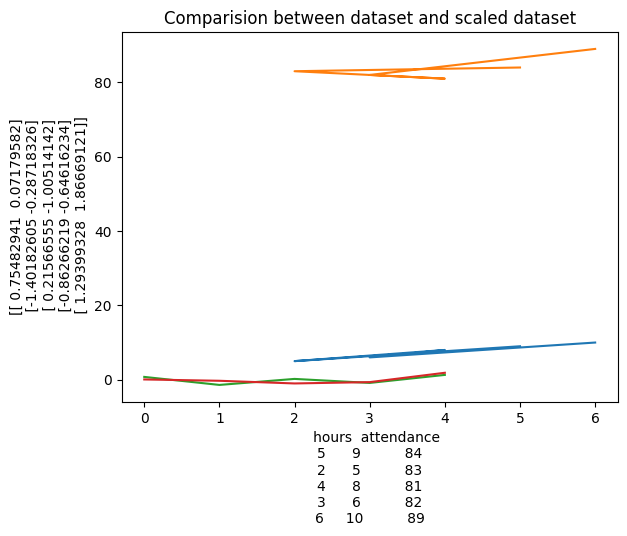

In [ ]:
plt.plot(X_train, label="Actual")
plt.plot(X_train_scaled , label="Scaled data")
plt.xlabel(X_train)
plt.ylabel(X_train_scaled)
plt.title("Comparision between dataset and scaled dataset")
plt.show()

New dataset for practice

In [ ]:
gym_data={
    "hours":[2,3,4,6,7,9,10],
    "attendance":[89,90,83,82,81,84,89],
    "fitness":[0,1,1,0,1,1,1]

}
df=pd.DataFrame(gym_data)
print(df)

   hours  attendance  fitness
0      2          89        0
1      3          90        1
2      4          83        1
3      6          82        0
4      7          81        1
5      9          84        1
6     10          89        1


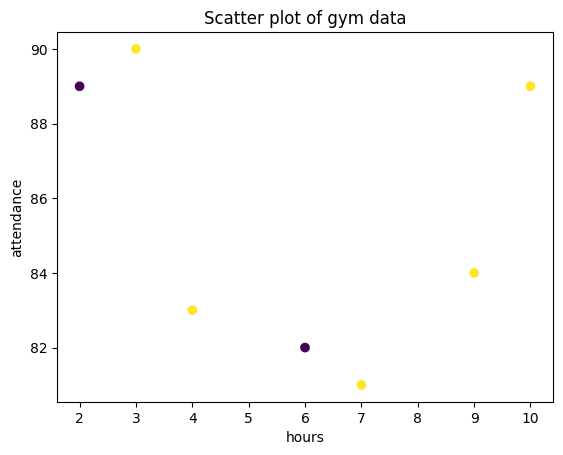

In [ ]:
plt.scatter(df["hours"],df["attendance"],c=df["fitness"])
plt.xlabel("hours")
plt.ylabel("attendance")
plt.title("Scatter plot of gym data")
plt.show()

In [ ]:
X=df[["hours","attendance"]]
Y=df["fitness"]
print(X.shape)
print(Y.shape)

(7, 2)
(7,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(Y_train.shape)

(5, 2)
(5,)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)
print(X_train_scaled)


[[ 0.84292723  0.07179582]
 [-1.4985373  -0.28718326]
 [-0.09365858 -1.00514142]
 [-0.56195149 -0.64616234]
 [ 1.31122014  1.86669121]]


In [ ]:
import tensorflow as tf
from tensorflow import keras
print("Imported successfully")

Imported successfully


In [ ]:
model=keras.Sequential([
    keras.layers.Dense(7,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")
])
print("Model created successfully")

Model created successfully


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
h=model.fit(
    X_train_scaled,
    Y_train,
    epochs=50
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 967ms/step - accuracy: 0.6000 - loss: 0.6315
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6000 - loss: 0.6296
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6000 - loss: 0.6278
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6000 - loss: 0.6259
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6000 - loss: 0.6241
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6000 - loss: 0.6222
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6000 - loss: 0.6203
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6000 - loss: 0.6184
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6000 - loss: 0.6165
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6000 - loss: 0.6146
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6000 - loss: 0.6127
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6000 - loss: 0.610

In [ ]:
loss, accuracy=model.evaluate(X_test_scaled,Y_test)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.6433
Test Loss: 0.6432962417602539
Test Accuracy: 1.0


In [ ]:
prediction=model.predict(X_test_scaled)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
[[0.4961255]
 [0.5481729]]


In [ ]:
new=[[11,99]]
sd=scaler.transform(new)
np=model.predict(sd)
print(np)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[[0.97443485]]


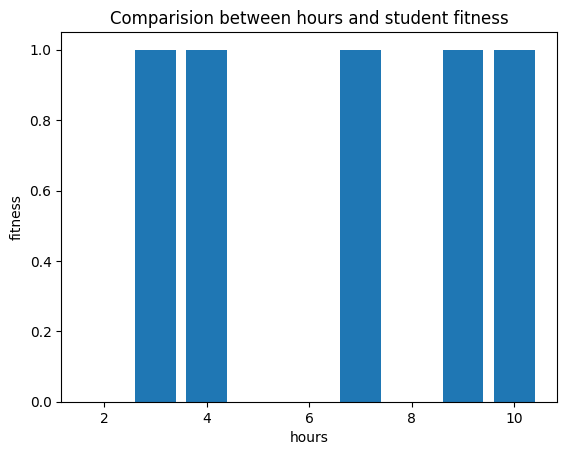

In [ ]:
plt.bar(df["hours"],df["fitness"])
plt.xlabel("hours")
plt.ylabel("fitness")
plt.title("Comparision between hours and student fitness")
plt.show()